# Euler Integration

This integration method is one of, if not the, simplest approach. Other methods modify Euler often improving it's accuracy by using better approximated changes, or by increasing efficiency of calculations using linear algebra. In any event, conceptually, Euler numerical integration of ODEs provides a simpler process to understand how it approximates solutions.

For this example, we will use 1D motion with drag. We start with the no drag model.

## Modeling 1D Falling Ball without Drag

Here, we know the net force is given by the weight of the ball (where $+y$ is upward),

$$F_{net,y} = - mg = m\ddot{y}.$$

So the second order ODE we are solving is,

$$\ddot{y} = -g.$$

It is overkill to solve this problem numerically, but it illustrates a nice conceptual point. Let's introduce,

$$\dot{y}=v_y,$$

the differential equation the defines the $y$ velocity. Then the other first order ODE that we need to ensure we have the same model is,

$$\dot{v}_y = -g.$$

These first order differential equations then can be transformed into the following two lines of code that will iteratively compute the velocity and position.

$$\dot{v}_y = -g \longrightarrow v_y[i+1] = v_y[i] - g \Delta t$$
$$\dot{y}=v_y \longrightarrow y[i+1] = y[i] + v_y[i] \Delta t$$

We implement that below with one small change, we compute the net force and then use that for the iteration.

$$F_{net,y} = -m*g$$
$$v_y[i+1] = v_y[i] + (F_{net,y}/m) \Delta t$$
$$y[i+1] = y[i] + v_y[i] \Delta t$$

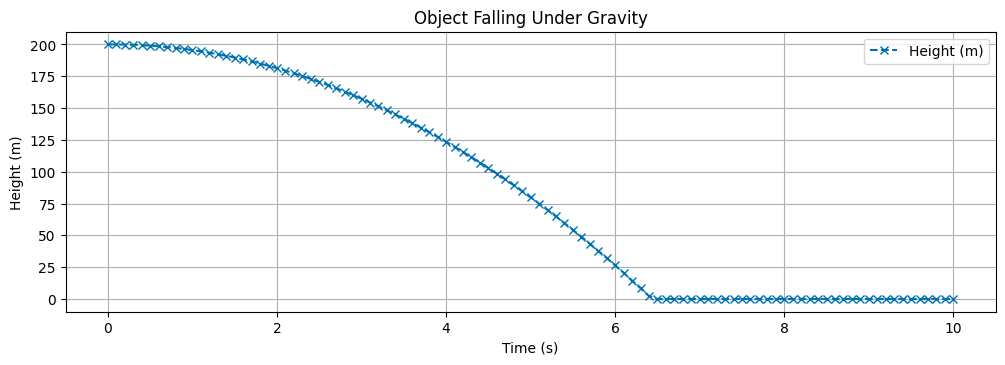

In [38]:
# Modeling constant acceleration due to gravity
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
plt.style.use('seaborn-v0_8-colorblind')

# Constants
mass = 1.0  # kg
g = 9.81  # m/s^2

# Time parameters
t_start = 0.0  # seconds
t_end = 10.0   # seconds
dt = 0.1       # time step in seconds

# Initial conditions
y0 = 200.0     # initial height in meters
v0 = 0.0       # initial velocity in m/s

# Time array
t = np.arange(t_start, t_end + dt, dt)

# Initialize arrays for height and velocity
y = np.zeros_like(t)
v = np.zeros_like(t)

# Set initial conditions
y[0] = y0
v[0] = v0

# Time-stepping loop using Euler's method
for i in range(0, len(t)-1):
    f_net = -1 * (mass * g)  # net force (downward)
    v[i+1] = v[i] + f_net / mass * dt  # update velocity
    y[i+1] = y[i] + v[i] * dt  # update height

    if y[i+1] < 0:  # stop if the object hits the ground
        y[i+1] = 0
        v[i+1] = 0
        break

# Plotting the results
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t, y, color='C0', marker='x', linestyle='--', label='Height (m)')
plt.title('Object Falling Under Gravity')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.grid()
plt.legend()

## Modeling 1D Falling Ball with Drag

Here, we know the net force is given by the weight of the ball (where $+y$ is upward) added to the drag force (modeled here $F_{drag} = C_Dv^2$),

$$F_{net,y} = - mg - C_D |v_y|v_y = m\ddot{y}.$$

Notice the difference here in the definition of the magnitude and how the equation featues in the differential equation. This is because the drag force is always opposite your velocity component $v_y$. We can derive the correct sign given our choice of coordinate system and direction of motion, but then we have a code that only works for that set up. This way, we can model motion correctly in any direction.

So the second order ODE we are solving is,

$$\ddot{y} = -g - \frac{C_D}{m} |v_y|v_y.$$

AGain, let's introduce,

$$\dot{y}=v_y,$$

the differential equation the defines the $y$ velocity. Then the other first order ODE that we need to ensure we have the same model is,

$$\dot{v}_y = -g - \frac{C_D}{m} |v_y|v_y.$$

These first order differential equations then can be transformed into the following two lines of code that will iteratively compute the velocity and position.

$$\dot{v}_y = -g - \frac{C_D}{m} |v_y|v_y \longrightarrow v_y[i+1] = v_y[i] - \left(g+ \frac{C_D}{m} |v_y[i]|\,v_y[i]\right)\Delta t$$
$$\dot{y}=v_y \longrightarrow y[i+1] = y[i] + v_y[i] \Delta t$$

We implement that below with one small change, we compute the net force and then use that for the iteration.

$$F_{net,y} = -m*g-C_D|v_y[i]|\,v_y[i]$$
$$v_y[i+1] = v_y[i] + (F_{net,y}/m) \Delta t$$
$$y[i+1] = y[i] + v_y[i] \Delta t$$

/var/folders/rh/mck_zfls1nz00lkh8jq3cpv80000gn/T/ipykernel_7596/2754186503.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


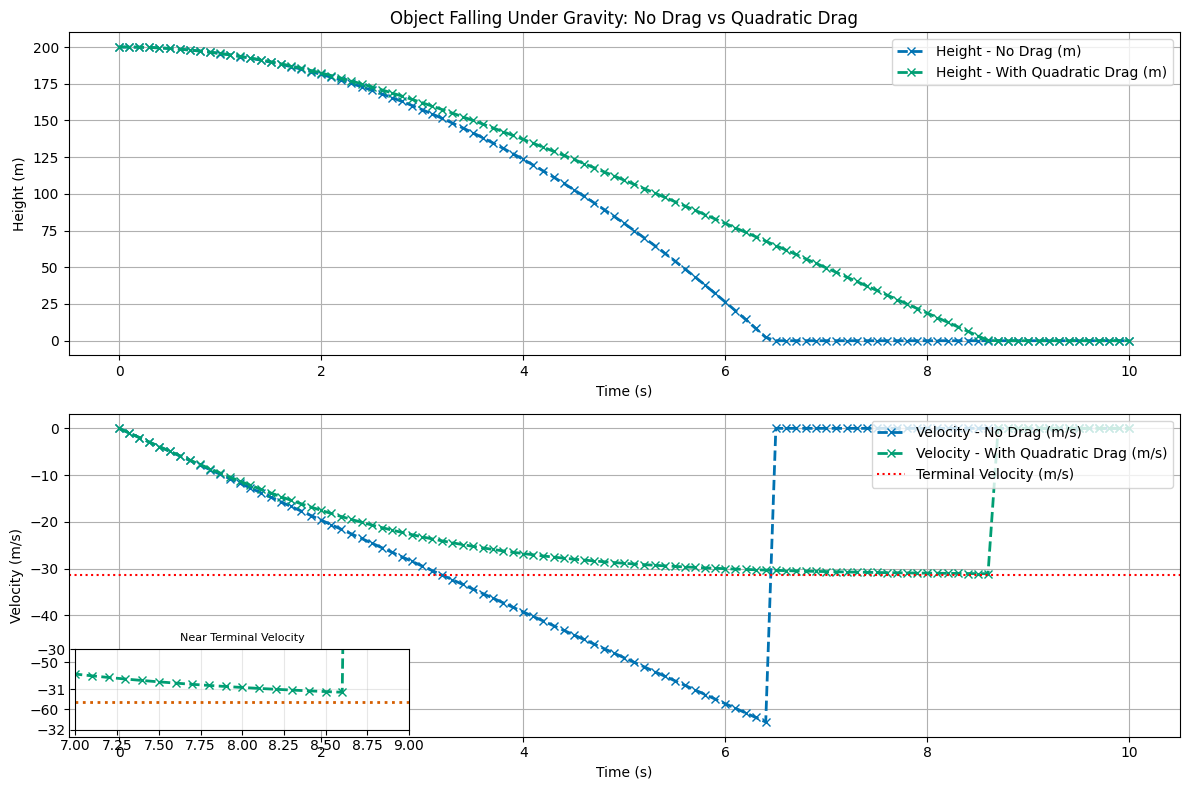

In [39]:
# Modeling constant acceleration due to gravity with quadratic drag
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.style.use('seaborn-v0_8-colorblind')

# Constants 
drag_coefficient = 0.01  # drag coefficient
mass = 1.0  # kg
g = 9.81  # m/s^2
vterm = np.sqrt(mass * g / drag_coefficient)  # terminal velocity

# Time parameters
t_start = 0.0  # seconds
t_end = 10.0   # seconds
dt = 0.1       # time step in seconds


# Reset arrays using existing variables
y_drag = np.zeros_like(t)
v_drag = np.zeros_like(t)

# Set initial conditions
y_drag[0] = y0
v_drag[0] = v0

# Time-stepping loop using Euler's method with quadratic drag
for i in range(0, len(t)-1):
    # Calculate drag force (opposing motion, proportional to v^2)
    f_drag = -drag_coefficient * v_drag[i] * abs(v_drag[i])  # quadratic drag
    f_gravity = -mass * g  # gravitational force
    f_net = f_gravity + f_drag  # total net force
    
    v_drag[i+1] = v_drag[i] + f_net / mass * dt  # update velocity
    y_drag[i+1] = y_drag[i] + v_drag[i] * dt  # update height

    if y_drag[i+1] < 0:  # stop if the object hits the ground
        y_drag[i+1] = 0
        v_drag[i+1] = 0
        break

# Plotting comparison between no drag and with drag
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, y, color='C0', marker='x', linestyle='--', label='Height - No Drag (m)', linewidth=2)
plt.plot(t, y_drag, color='C1', marker='x', linestyle='--', label='Height - With Quadratic Drag (m)', linewidth=2)
plt.title('Object Falling Under Gravity: No Drag vs Quadratic Drag')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, v, color='C0', marker='x', linestyle='--', label='Velocity - No Drag (m/s)', linewidth=2)
plt.plot(t, v_drag, color='C1', marker='x', linestyle='--', label='Velocity - With Quadratic Drag (m/s)', linewidth=2)
plt.axhline(-vterm, color='r', linestyle=':', label='Terminal Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.grid()
plt.legend(loc='upper right')

# Inset plot to show closer view around 8.5 seconds when velocity approaches terminal
axins = inset_axes(plt.gca(), width="30%", height="25%", loc='lower left')
axins.plot(t, v_drag, color='C1', linewidth=2, marker='x', linestyle='--')
axins.axhline(-vterm, color='C2', linestyle=':', linewidth=2)
axins.set_xlim(7, 9)
axins.set_ylim(-32, -30)
axins.grid(True, alpha=0.3)
axins.set_title('Near Terminal Velocity', fontsize=8)

plt.tight_layout()
plt.show()